# 1. Load Packages and Data Files

In [1]:
# Cell 1: Load packages and data files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Adjust paths to step out of the notebooks/ directory up to the project root
DATA_DIR = Path("../data/baseline")

# 1. Load the fast-track continuous time-series metrics
df_scalars = pd.read_csv(DATA_DIR / "baseline_scalars.csv")

# 2. Load the compressed alpha parameters snapshot archive
# This acts like a lazy dictionary mapping string steps to (N, K) arrays
alpha_archive = np.load(DATA_DIR / "baseline_alpha_snapshots.npz")

print("Fast-track telemetry loaded successfully. Shape:", df_scalars.shape)
print(f"Slow-track archived evaluation checkpoints found: {list(alpha_archive.keys())}")

Fast-track telemetry loaded successfully. Shape: (10000, 7)
Slow-track archived evaluation checkpoints found: ['0', '200', '400', '600', '800', '1000', '1200', '1400', '1600', '1800', '2000', '2200', '2400', '2600', '2800', '3000', '3200', '3400', '3600', '3800', '4000', '4200', '4400', '4600', '4800', '5000', '5200', '5400', '5600', '5800', '6000', '6200', '6400', '6600', '6800', '7000', '7200', '7400', '7600', '7800', '8000', '8200', '8400', '8600', '8800', '9000', '9200', '9400', '9600', '9800']


In [2]:
# Cell 2: On-demand metric calculation for checkpoints
from utils.math_utils import compute_jeffreys_divergence_matrix
from analysis.metrics import calculate_dirichlet_population_divergence

# Gather checkpoints and sort them chronologically as integers
checkpoint_steps = sorted([int(k) for k in alpha_archive.keys()])
continuous_distances = []

print("Processing deferred O(N^2) metrics for checkpoints...")
for step in checkpoint_steps:
    # Pull out the (N, K) matrix using the string key representation
    alphas_at_t = alpha_archive[str(step)]
    
    # Calculate the exact Jeffreys matrix configuration for this step snapshot
    j_matrix = compute_jeffreys_divergence_matrix(alphas_at_t)
    
    # Extract the mean unique distance scalar across the population
    distance_scalar = calculate_dirichlet_population_divergence(j_matrix)
    continuous_distances.append(distance_scalar)

print("Calculation complete! Matched checkpoints processed:", len(continuous_distances))

Processing deferred O(N^2) metrics for checkpoints...
Calculation complete! Matched checkpoints processed: 50


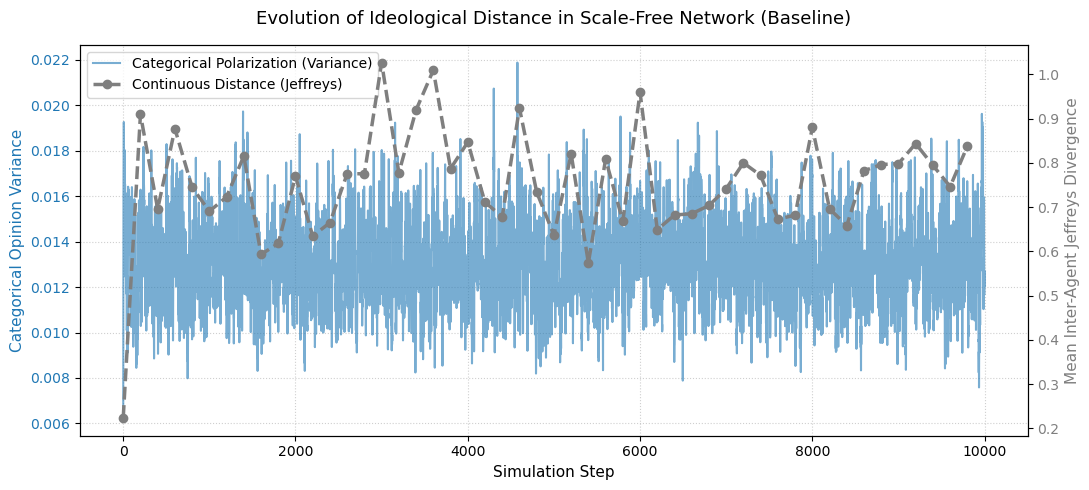

In [3]:
# Cell 3: System Telemetry Charting
fig, ax1 = plt.subplots(figsize=(11, 5), dpi=100)

# Axis 1: Categorical Variance (Fast-track)
color_var = "#1f77b4"
ax1.plot(df_scalars["step"], df_scalars["polarization"], 
         label="Categorical Polarization (Variance)", color=color_var, alpha=0.6, linewidth=1.5)
ax1.set_xlabel("Simulation Step", fontsize=11)
ax1.set_ylabel("Categorical Opinion Variance", color=color_var, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_var)

# Axis 2: Continuous Divergence (Slow-track checkpoints)
ax2 = ax1.twinx()
color_jeff = "#7f7f7f"  # Standard distinct neutral color for lines
ax2.plot(checkpoint_steps, continuous_distances, 
         label="Continuous Distance (Jeffreys)", color=color_jeff, 
         marker="o", markersize=6, linewidth=2.5, linestyle="--")
ax2.set_ylabel("Mean Inter-Agent Jeffreys Divergence", color=color_jeff, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color_jeff)

# Clean styling treatments
plt.title("Evolution of Ideological Distance in Scale-Free Network (Baseline)", fontsize=13, pad=15)
ax1.grid(True, linestyle=":", alpha=0.6)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

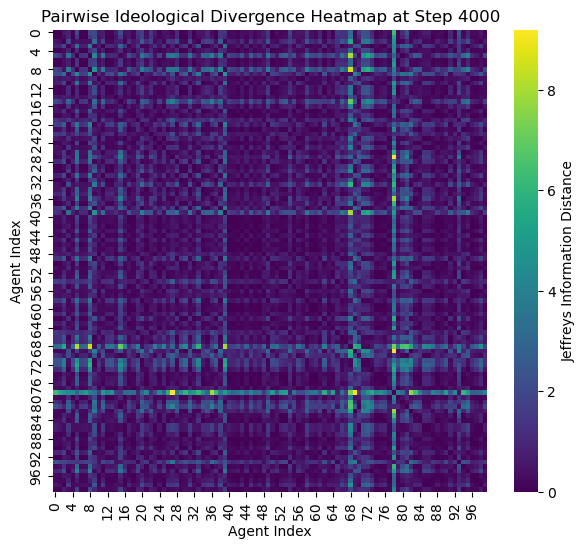

In [4]:
# Cell 4: Extract and view a high-fidelity fingerprint matrix
target_step = "4000"  # Modify to analyze any logged step index

if target_step in alpha_archive:
    alphas_snapshot = alpha_archive[target_step]
    
    # Calculate the clean distance fingerprints
    j_matrix_snapshot = compute_jeffreys_divergence_matrix(alphas_snapshot)
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(j_matrix_snapshot, cmap="viridis", cbar_kws={'label': 'Jeffreys Information Distance'})
    plt.title(f"Pairwise Ideological Divergence Heatmap at Step {target_step}")
    plt.xlabel("Agent Index")
    plt.ylabel("Agent Index")
    plt.show()
else:
    print(f"Step {target_step} was not cached in this simulation run config.")